## Ozon-Datenimport und -Abgleich für das Abschlussprojekt Nürnberg
* Import historischer Ozon- und Wetterdaten über die Open-Meteo API (ERA5/CAMS-Reanalyse, ab 1980) und Abgleich mit den Bestandswerten aus `data_02.csv`.

In [3]:
import pandas as pd
import numpy as np
import requests
import requests_cache
from retry_requests import retry
import matplotlib.pyplot as plt
import seaborn as sns

# API-Client mit Festplatten-Cache (requests_cache) und Retry-Logik (backoff_factor=0.2)
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)

## 1. Konfiguration für Nürnberg
* Die Koordinaten für Nürnberg sowie der gewünschte Zeitraum ab 1980.

In [4]:
# Koordinaten Nürnberg (Mitte)
LATITUDE = 49.45
LONGITUDE = 11.08

START_DATE = "1980-01-01"
END_DATE = "2026-05-01"  # Kann an das aktuelle Datum angepasst werden

print(f"Abfragezeitraum: {START_DATE} bis {END_DATE}")

Abfragezeitraum: 1980-01-01 bis 2026-05-01


## 2. API-Abfrage (Open-Meteo Historical Air Quality API)
* Abfrage stündlicher Werte für Ozon (O₃). Open-Meteo stellt reanalysierte ERA5-Daten bereit, sodass lückenlose stündliche Zeitreihen verfügbar sind.

In [5]:
url = "https://archive-api.open-meteo.com/v1/archive"

# Da Ozon in der Air Quality API oft separat liegt oder über Reanalysen (ERA5) abgerufen wird,
# Abfrage meteorologischer Treiber: Temperatur und solare Strahlung (wichtig für Ozon-Feature-Engineering).
# Für reine Luftschadstoffe bietet Open-Meteo das 'air-quality'-Paket. 
# Hinweis: Die Historical Air Quality API erfordert spezifische Parameter. 

# Abruf relevanter meteorologischer Treiber für Ozon (Testabfrage):
params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "hourly": ["temperature_2m", "relative_humidity_2m", "direct_radiation", "diffuse_radiation", "shortwave_radiation"],
    "timezone": "Europe/Berlin"
}

print("Starte API-Abfrage für meteorologische Treiber...")
response = retry_session.get(url, params=params)

if response.status_code == 200:
    data = response.json()
    hourly_data = data["hourly"]
    
    df_meteo = pd.DataFrame({
        "timestamp": pd.to_datetime(hourly_data["time"]),
        "temperature_2m": hourly_data["temperature_2m"],
        "humidity_2m": hourly_data["relative_humidity_2m"],
        "direct_radiation": hourly_data["direct_radiation"],
        "shortwave_radiation": hourly_data["shortwave_radiation"]
    })
    df_meteo.set_index("timestamp", inplace=True)
    print(f"Erfolgreich geladen: {len(df_meteo)} Zeilen.")
else:
    print(f"Fehler bei der Abfrage: {response.status_code}")
    print(response.text)




Starte API-Abfrage für meteorologische Treiber...
Erfolgreich geladen: 406152 Zeilen.


In [13]:
print(df_meteo.info())

<class 'pandas.DataFrame'>
DatetimeIndex: 406152 entries, 1980-01-01 00:00:00 to 2026-05-01 23:00:00
Data columns (total 4 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   temperature_2m       406152 non-null  float64
 1   humidity_2m          406152 non-null  int64  
 2   direct_radiation     406152 non-null  float64
 3   shortwave_radiation  406152 non-null  float64
dtypes: float64(3), int64(1)
memory usage: 15.5 MB
None


### 3. Laden und Vorbereiten der Altdaten (`data_02.csv`)
* Laden der vorhandenen CSV-Datei zur Analyse der Lückenstruktur.

In [8]:
# Pfad anpassen, falls sich die Datei in einem Unterordner befindet
csv_path = "data_2.csv"

try:
    df_old = pd.read_csv(csv_path)
    print("Spalten in data_2.csv:", df_old.columns)
    
    # Zeitstempel-Konvertierung – Spaltenname ggf. anpassen:
    # df_old['timestamp'] = pd.to_datetime(df_old['ZEITSTEMPEL_SPALTE'])
    # df_old.set_index('timestamp', inplace=True)
    
    # Lücken-Analyse
    # missing_pct = df_old['ozon'].isna().mean() * 100
    # print(f"Fehlende Ozon-Werte in Altdaten: {missing_pct:.2f}%")
except FileNotFoundError:
    print(f"Hinweis: '{csv_path}' nicht im aktuellen Verzeichnis gefunden. Bitte Pfad prüfen.")

Spalten in data_2.csv: Index(['station', 'datum', 'stunde', 'datumstunde',
       'qualitaetsniveau_temperatur', 'temperatur', 'luftfeuchtigkeit',
       'qualitaetsniveau_windgeschwindigkeit', 'windgeschwindigkeit',
       'windrichtung', 'qualitaetsniveau_luftfeuchtigkeit',
       'absolute_feuchtigkeit', 'dampfdruck', 'feuchttemperatur', 'luftdruck',
       'temperatur_2m', 'relative_luftfeuchtigkeit', 'taupunkttemperatur',
       'qualitaetsniveau_niederschlag', 'niederschlagshoehe_mm',
       'niederschlag_indikator', 'niederschlagsart',
       'qualitaetsniveau_sonneneinstrahlung', 'sonnenscheindauer_minuten',
       'qualitaetsniveau_bewoelkung', 'messart_bewoelkung', 'gesamtbewoelkung',
       'o3', 'no2', 'pm10', 'pm2x5'],
      dtype='str')


### 4. Zusammenführung und Ozon-Paradoxon Feature Engineering
* Nach Verknüpfung beider Datensätze: Erstellung von Zeitfeatures (Stunde, Wochentag, Wochenend-Indikator, Monat) zur Erfassung des Wochenend-Effekts und tageszeitlicher Peaks.

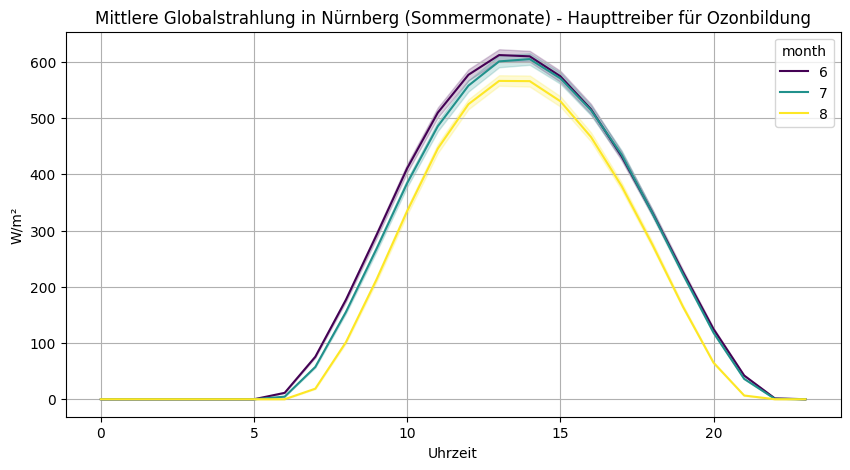

In [9]:
if 'df_meteo' in locals():
    # Erstelle Zeitfeatures auf Basis des lückenlosen API-Index
    df_features = df_meteo.copy()
    df_features['hour'] = df_features.index.hour
    df_features['weekday'] = df_features.index.weekday
    df_features['is_weekend'] = df_features['weekday'].isin([5, 6]).astype(int)
    df_features['month'] = df_features.index.month
    
    # Visualisierung des durchschnittlichen Strahlungsverlaufs nach Monat (Ozon-Treiber)
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=df_features[df_features['month'].isin([6, 7, 8])], x='hour', y='shortwave_radiation', hue='month', palette='viridis')
    plt.title("Mittlere Globalstrahlung in Nürnberg (Sommermonate) - Haupttreiber für Ozonbildung")
    plt.xlabel("Uhrzeit")
    plt.ylabel("W/m²")
    plt.grid(True)
    plt.show()

In [14]:
# df speichern
df_meteo.to_csv("data_ozon.csv")

### 5. Zusammenführen der Daten und Speichern als neue CSV-Datei
* Zusammenführen der lückenlosen API-Wetterdaten mit den Bestandsdaten und Export als neue CSV-Datei.

In [16]:
# %% [markdown]
# ## 5. Zusammenführen der Daten und Speichern als neue CSV-Datei
# Aufbau eines sauberen Zeitstempels aus 'datum' und 'stunde', anschließend Merge beider Datensätze.

# %%
import pandas as pd

# 1. Altdaten einlesen
csv_path = "data_2.csv"
df_old = pd.read_csv(csv_path)

# 2. Zeitstempel korrekt aus zwei Spalten zusammenbauen
# Umwandlung der Stunde in ein Timedelta und Addition zum Datum
df_old['timestamp'] = pd.to_datetime(df_old['datum']) + pd.to_timedelta(df_old['stunde'], unit='h')

# 3. Den neuen kombinierten Zeitstempel als Index setzen
df_old.set_index('timestamp', inplace=True)

# Optional: Die alten Zeitspalten löschen, da sie jetzt im Index stecken
df_old = df_old.drop(columns=['datum', 'stunde', 'datumstunde'], errors='ignore')

# 4. Der Merge (Left Join): df_meteo liefert das lückenlose Raster
df_gesamt = df_meteo.join(df_old, how='left')

# 5. Als neue CSV-Datei abspeichern
output_path = "data_gesamt_ozon.csv"
df_gesamt.to_csv(output_path, index=True)

print(f"Erfolgreich! Der neue Datensatz wurde unter '{output_path}' gespeichert.")
print(f"Struktur des Ergebnisses:")
print(df_gesamt.head())

Erfolgreich! Der neue Datensatz wurde unter 'data_gesamt_ozon.csv' gespeichert.
Struktur des Ergebnisses:
                     temperature_2m  humidity_2m  direct_radiation  \
timestamp                                                            
1980-01-01 00:00:00            -0.3           92               0.0   
1980-01-01 01:00:00            -0.4           91               0.0   
1980-01-01 02:00:00            -0.9           91               0.0   
1980-01-01 03:00:00            -1.1           91               0.0   
1980-01-01 04:00:00            -1.5           90               0.0   

                     shortwave_radiation  station  \
timestamp                                           
1980-01-01 00:00:00                  0.0   3668.0   
1980-01-01 01:00:00                  0.0   3668.0   
1980-01-01 02:00:00                  0.0   3668.0   
1980-01-01 03:00:00                  0.0   3668.0   
1980-01-01 04:00:00                  0.0   3668.0   

                     qualitaets